# DESeq2 with new reference genome
# Phase 1 vs. Phase 1

focusing on pairwise comparisons involving oysters that experienced only **one** phase 1 (one exposure)

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)
library(vegan)
library(pheatmap)
library(RColorBrewer)

## 1. read counts matrix and meta data

### counts matrix
the counts matrix was generated in [processing_seqs.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/processing_seqs.ipynb) with the new reference genome ([NCBI GCF_053477285.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)), indexed and aligned with `hisat2`, and counts matrix generated with `featureCounts` (all with the same flags/settings that were used with the old genome)

In [3]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts <- counts %>%
select(-Gene_ID, -Length)

head(counts)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


### meta data

In [4]:
# create df with col names from counts matrix
meta <- as.data.frame(colnames(counts))

colnames(meta) <- 'Sample'

# Separate into columns
meta <- meta %>%
   # Keep original SampleID
  mutate(OGSample = Sample) %>%
  # Split by '_'
  separate(Sample, into = c("Phase1", "Phase2", "Tag"), sep = "_") %>%
  mutate(
    Phase1_Treatment = substr(Phase1, 1, 1),
    Phase1_TankRep    = as.numeric(substr(Phase1, 2, nchar(Phase1))),
    Phase2_Treatment = gsub("[0-9]", "", Phase2),
    Phase2_TankRep       = as.numeric(gsub("[A-Za-z]", "", Phase2))
  ) %>%
  select(OGSample, Phase1_Treatment, Phase1_TankRep, Phase2_Treatment, Phase2_TankRep, Tag)

colnames(meta)[1] <- 'Sample'

head(meta)

,Sample,Phase1_Treatment,Phase1_TankRep,Phase2_Treatment,Phase2_TankRep,Tag
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>
1,B1_B1_O01,B,1,B,1,O01
2,B1_Nu_O03,B,1,Nu,NA,O03
3,B1_W5_O50,B,1,W,5,O50
4,B2_B5_O51,B,2,B,5,O51
5,B2_C4_O40,B,2,C,4,O40
6,B2_Nu_O12,B,2,Nu,NA,O12


In [5]:
# adding treatment info
meta2 <- meta %>%
mutate(
    ## phase 1 treatments
    # overall
    Phase1_treatment = case_when(
        Phase1_Treatment == 'B' ~ 'both',
        Phase1_Treatment == 'H' ~ 'hypoxic',
        Phase1_Treatment == 'W' ~ 'warm',
        Phase1_Treatment == 'C' ~ 'control',
    TRUE ~ NA_character_),
    
    # temp
    Phase1_temp = case_when(
        Phase1_Treatment == 'B' ~ 'warm',
        Phase1_Treatment == 'H' ~ 'ambient',
        Phase1_Treatment == 'W' ~ 'warm',
        Phase1_Treatment == 'C' ~ 'ambient',
    TRUE ~ NA_character_),

    # dissolved oxygen
    Phase1_DO = case_when(
        Phase1_Treatment == 'B' ~ 'hypoxic',
        Phase1_Treatment == 'H' ~ 'hypoxic',
        Phase1_Treatment == 'W' ~ 'normoxic',
        Phase1_Treatment == 'C' ~ 'normoxic',
    TRUE ~ NA_character_),
    
    ## phase 2 treatments
    # overall
    Phase2_treatment = case_when(
        Phase2_Treatment == 'B' ~ 'both',
        Phase2_Treatment == 'H' ~ 'hypoxic',
        Phase2_Treatment == 'W' ~ 'warm',
        Phase2_Treatment == 'C' ~ 'control',
    TRUE ~ NA_character_),
    
    # temp
    Phase2_temp = case_when(
        Phase2_Treatment == 'B' ~ 'warm',
        Phase2_Treatment == 'H' ~ 'ambient',
        Phase2_Treatment == 'W' ~ 'warm',
        Phase2_Treatment == 'C' ~ 'ambient',
    TRUE ~ NA_character_),

    # dissolved oxygen
    Phase2_DO = case_when(
        Phase2_Treatment == 'B' ~ 'hypoxic',
        Phase2_Treatment == 'H' ~ 'hypoxic',
        Phase2_Treatment == 'W' ~ 'normoxic',
        Phase2_Treatment == 'C' ~ 'normoxic',
    TRUE ~ NA_character_)) %>%
select(Sample, Phase1_treatment, Phase1_temp, Phase1_DO, Phase1_TankRep, Phase2_treatment, Phase2_temp, Phase2_DO, Phase2_TankRep)

head(meta2)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


In [6]:
#write.csv(meta2, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/sample_metaData.csv', row.names=FALSE)

for this analysis, only looking at Phase 1 samples, so pulling those out

In [7]:
# if skipped above code:
meta2 <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')

In [8]:
# selecting only phase 1 sample
p1_meta <- meta2 %>%
filter(grepl("Nu", Sample)) %>%
filter(Sample != 'B3_Nu_O24') # this sample failed all QC steps, removing from analysis

# setting samples as rownames and deleting col from df
rownames(p1_meta) <- p1_meta$Sample
p1_meta <- p1_meta[, !colnames(p1_meta) %in% "Sample"]

p1_meta

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA
C1_Nu_W05,control,ambient,normoxic,1,NA,NA,NA,NA
C2_Nu_W15,control,ambient,normoxic,2,NA,NA,NA,NA
C3_Nu_W21,control,ambient,normoxic,3,NA,NA,NA,NA


In [9]:
# pulling out only phase 1 counts
p1_counts <- counts[,colnames(counts) %in% rownames(p1_meta)]
head(p1_counts)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2649,3974,2721,2246,2606,2804,2840,2829,2376,3580,⋯,2518,2269,3011,3027,3384,2316,2342,3478,2734,2374
LOC144621269,580,20011,11469,21,86,9642,2179,2944,4120,3621,⋯,7163,2405,217,35998,11679,2489,3926,11926,2,4034
LOC111120925,4,18,27,2,8,22,339,350,269,7,⋯,301,15,238,167,9,284,6,7,0,11
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [10]:
# setting the same order for counts matrix and meta data
p1_counts <- p1_counts[,rownames(p1_meta)]
all(rownames(p1_meta) == colnames(p1_counts))

[1] TRUE

## 2. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [11]:
# overall phase 1 treatment
p1_meta$Phase1_treatment <- factor(p1_meta$Phase1_treatment,
                                   levels = c('control', 'both', 'hypoxic', 'warm'))

In [12]:
# phase 1 tempature
p1_meta$Phase1_temp <- factor(p1_meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

In [13]:
# phase 1 DO
p1_meta$Phase1_DO <- factor(p1_meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

### phase 1 overall treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [14]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = p1_counts,
                              colData = p1_meta,
                              design = ~ Phase1_treatment)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

class: DESeqDataSet 
dim: 33903 23 
metadata(1): version
assays(1): counts
rownames(33903): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(8): Phase1_treatment Phase1_temp ... Phase2_DO
  Phase2_TankRep

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "Intercept"                           "Phase1_treatment_both_vs_control"   
[3] "Phase1_treatment_hypoxic_vs_control" "Phase1_treatment_warm_vs_control"

In [15]:
vsd <- vst(dds, blind = TRUE) # DESeq "forgets" the design/groups, applies vst evenly across samples
head(assay(vsd))

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC144621260,11.258801,11.960032,11.265406,11.422507,11.525520,11.368300,11.650335,11.631261,10.984830,11.384886,⋯,11.725396,11.200459,11.688711,12.023181,11.406467,11.518793,11.200654,11.728272,11.498320,11.629129
LOC144621269,9.382063,14.238993,13.258988,7.242824,7.900472,13.079421,11.291963,11.685592,11.724895,11.400237,⋯,13.183337,11.278334,8.591565,15.536763,13.124600,11.616661,11.901563,13.451033,6.723423,12.360217
LOC111120925,6.790123,7.133028,7.222546,6.738875,6.949505,7.169359,9.046805,9.069082,8.527882,6.843712,⋯,9.104683,7.079873,8.675046,8.570575,6.901862,8.976325,6.866471,6.893820,6.510761,7.069393
Trnae-cuc,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,⋯,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761
Trnae-cuc-2,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,⋯,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761
Trnae-cuc-3,6.510761,6.658506,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,⋯,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761


In [15]:
write.csv(assay(vsd), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/p1_vst.csv')

### diagnostic tests

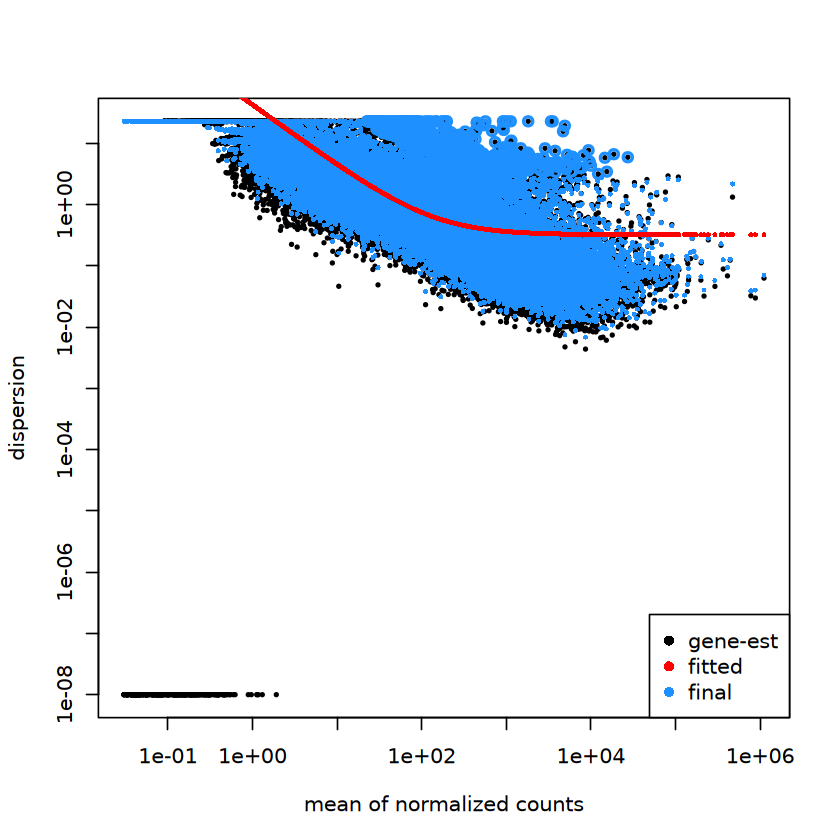

In [16]:
plotDispEsts(dds)

## nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [64]:
# normalization & transformation
vsd <- vst(dds)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.0000,155.0745,146.8302,134.2455,126.8144,139.6373,134.8313,144.8294,132.6799,128.0759,⋯,162.2819,132.30217,130.3965,180.4915,142.6394,138.0217,126.2580,139.3330,118.2161,132.4806
B2_Nu_O12,155.0745,0.0000,130.8257,174.8181,165.3156,127.4121,146.2691,148.8189,142.5726,129.6997,⋯,137.9343,135.00571,168.4332,133.2346,137.4765,143.7396,141.7791,131.5602,159.4648,131.9203
B4_Nu_O32,146.8302,130.8257,0.0000,156.0272,150.8728,134.4563,134.0006,131.7701,129.7965,130.5976,⋯,140.6767,97.86428,152.8005,135.4833,131.5668,140.5304,144.8051,125.1475,158.3632,126.9045
B5_Nu_O36,134.2455,174.8181,156.0272,0.0000,126.5524,162.9903,142.0701,143.4507,137.1746,150.6686,⋯,173.9805,142.37887,130.7690,188.8840,146.7381,158.2430,162.2096,153.8362,147.0975,145.7801
B6_Nu_O47,126.8144,165.3156,150.8728,126.5524,0.0000,153.3062,141.3715,134.6910,133.5992,139.6751,⋯,159.0065,132.61031,126.5869,185.2680,135.5390,153.7387,150.8260,134.0637,136.8299,135.2230
C1_Nu_W01,139.6373,127.4121,134.4563,162.9903,153.3062,0.0000,135.0684,141.9270,135.9188,120.1587,⋯,140.4389,132.53801,157.1133,146.4176,125.3859,135.1210,135.6165,126.5769,145.1248,126.8863


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>
B1_Nu_O03,50.09153,-33.929416,both,warm,hypoxic,1,NA,NA,NA,NA,1.1662324
B2_Nu_O12,-57.98730,-29.901471,both,warm,hypoxic,2,NA,NA,NA,NA,1.0447462
B4_Nu_O32,-30.31702,2.715691,both,warm,hypoxic,4,NA,NA,NA,NA,1.1920377
B5_Nu_O36,71.14173,18.094849,both,warm,hypoxic,5,NA,NA,NA,NA,0.8754641
B6_Nu_O47,59.91973,1.428441,both,warm,hypoxic,6,NA,NA,NA,NA,0.9413226
C1_Nu_W01,-31.17501,-37.462505,control,ambient,normoxic,1,NA,NA,NA,NA,1.1378061


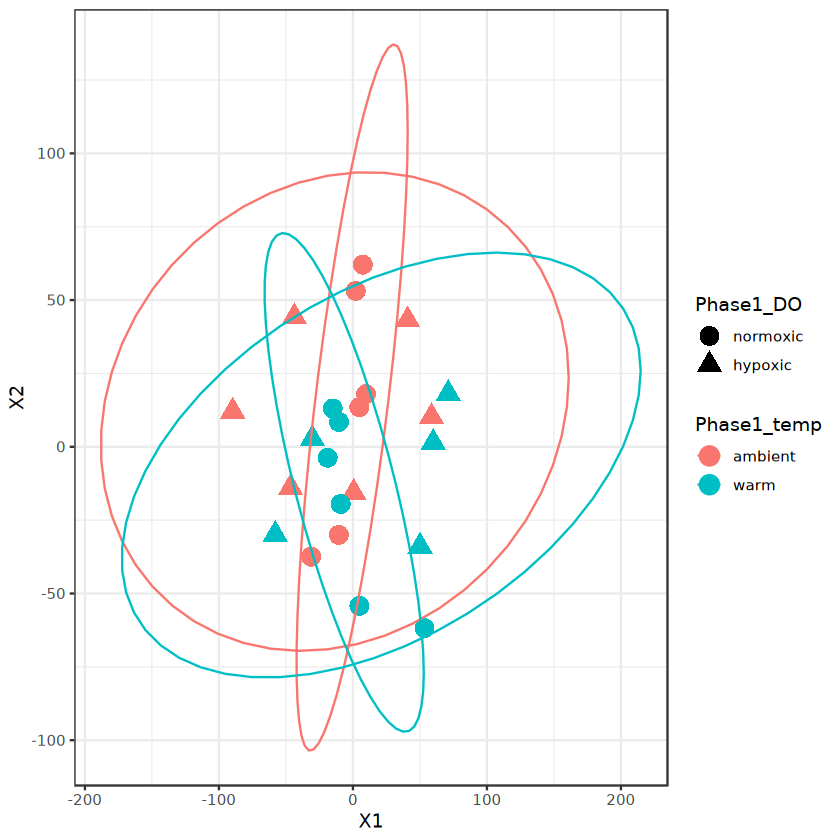

In [18]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

There doesn't appear to be any strong patterns of gene expression among the different phase 1 treatments

but the warm treatment looks less disperse than ambient treatment

#### permANOVA

In [21]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO, data = p1_meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,12096.416,0.05514581,1.2115054,0.158
Phase1_DO,1,9369.602,0.04271466,0.9384039,0.539
Phase1_temp:Phase1_DO,1,8179.608,0.03728964,0.8192211,0.788
Residual,19,189707.697,0.86484989,NA,NA
Total,22,219353.322,1.00000000,NA,NA


permANOVA confirms that there isn't any statistically significant differences in gene expression patterns among phase 1 treatments 

### heatmap

In [22]:
# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

[1] 155.0745 146.8302 134.2455 126.8144 139.6373 134.8313

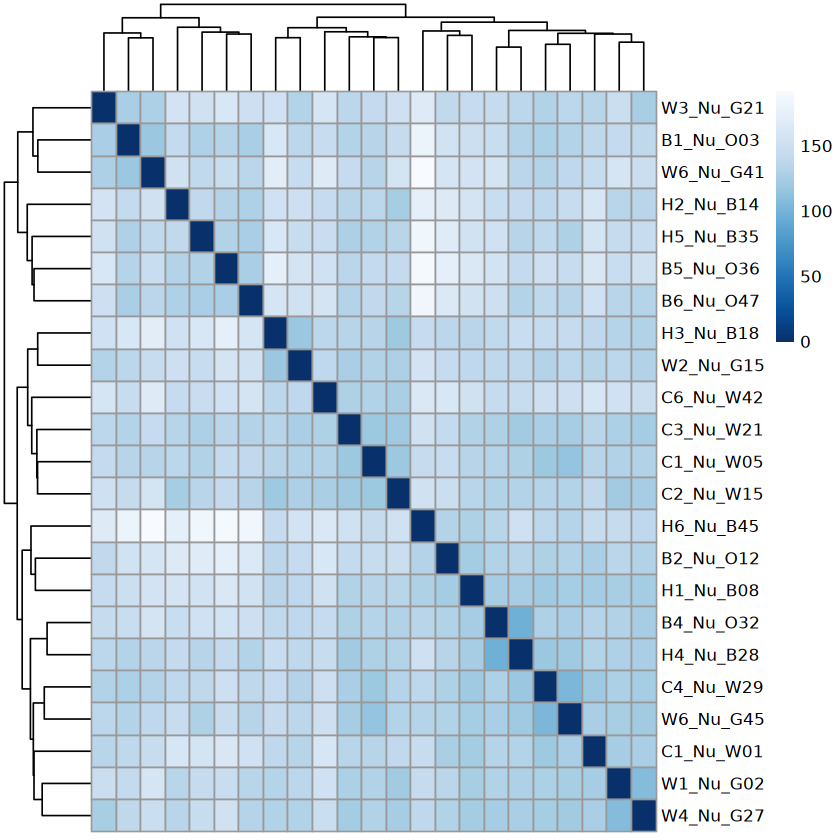

In [23]:
sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

### comparisons vs. control
applying `ashr` lfc shrinkage estimator - DESeq docs recommend `apeglm` but cannot use that for comparisons below so I want everything to be consistent

#### warm vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28705 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 25, 0.087%
LFC < -1.00 (down) : 40, 0.14%



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7661933,0.0041376006,0.05479417,0.27170722,0.78584715,0.9866898,0.9914836,2271.416959,3.803795e+03,⋯,3206.1520,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,LOC144621269,6797.3813723,0.0042846374,0.10625915,0.45989202,0.64559373,0.9763304,0.9837326,497.327987,1.915393e+04,⋯,9120.5983,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,LOC111120925,191.4430470,-0.1617284107,0.65118025,-2.57799792,0.00993746,0.3655716,0.6796401,3.429848,1.722906e+01,⋯,383.2612,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,Trnae-cuc,0.0000000,0.0000000000,1.09814472,NA,NA,NA,0.9421386,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
5,Trnae-cuc-2,0.0000000,0.0000000000,1.09814472,NA,NA,NA,0.9421521,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
6,Trnae-cuc-3,0.3001343,0.0002446391,0.22593887,0.01996082,0.98407463,NA,0.9788322,0.000000,9.571703e-01,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


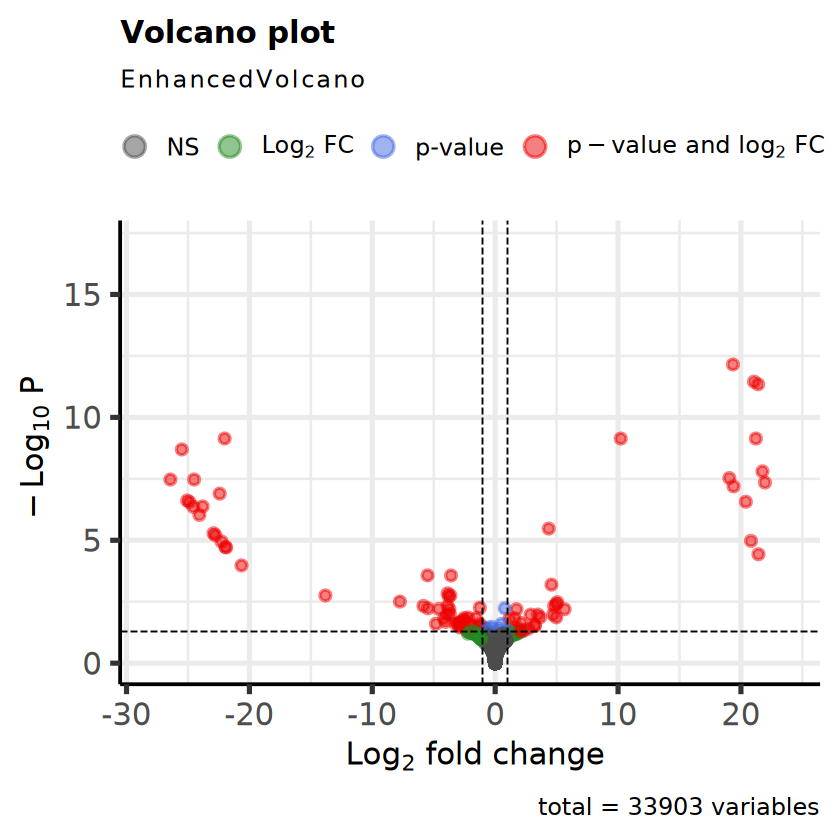

In [24]:
# phase 1 warm vs. control
res.warmLFC <- lfcShrink(dds, 
                         coef=4, 
                         type = 'ashr',
                        lfcThreshold = 1)

summary(res.warmLFC)

EnhancedVolcano(res.warmLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.warmLFC <- merge(res.warmLFC, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.warmLFC)[1] <- 'Gene'
head(res.warmLFC)

In [25]:
write.csv(as.data.frame(res.warmLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.warm_v_cont.csv')

#### hypoxic vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28705 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 15, 0.052%
LFC < -1.00 (down) : 27, 0.094%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7661933,0.010052042,0.0456922,0.9371050,0.3487045,0.9778766,0.9960505,2271.416959,3.803795e+03,⋯,3206.1520,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,LOC144621269,6797.3813723,0.006921440,0.1061581,1.5501091,0.1211153,0.9106849,0.9845355,497.327987,1.915393e+04,⋯,9120.5983,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,LOC111120925,191.4430470,-0.006471049,0.1054800,-1.4865526,0.1371330,0.9302162,0.9848393,3.429848,1.722906e+01,⋯,383.2612,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,Trnae-cuc,0.0000000,0.000000000,0.8490139,NA,NA,NA,0.9472006,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
5,Trnae-cuc-2,0.0000000,0.000000000,0.8490139,NA,NA,NA,0.9472261,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
6,Trnae-cuc-3,0.3001343,0.003854557,0.1790991,0.6129463,0.5399118,NA,0.9859547,0.000000,9.571703e-01,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


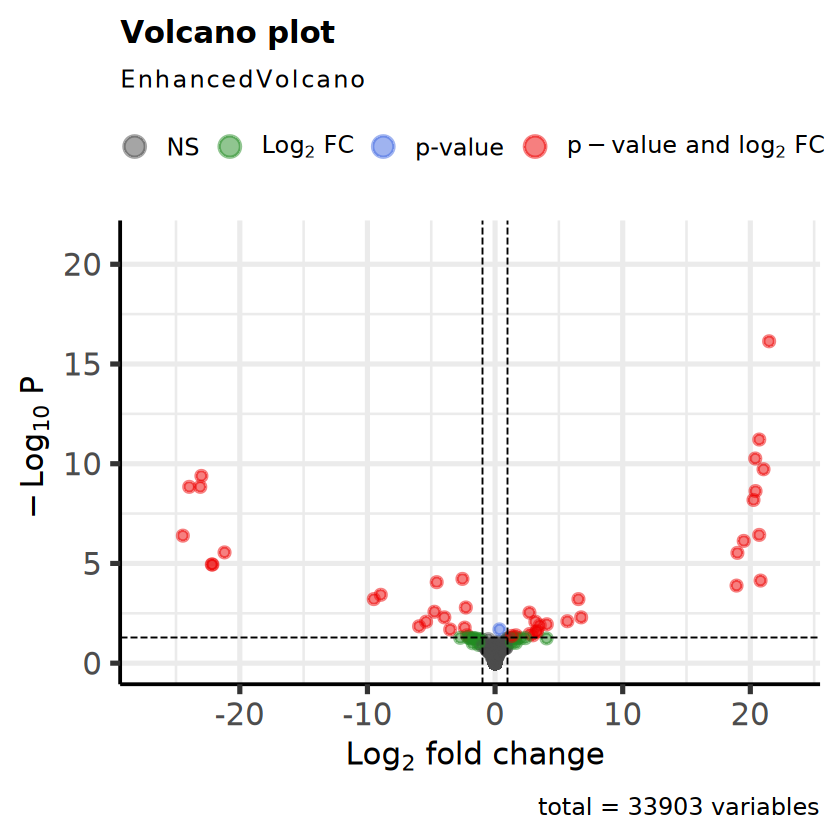

In [26]:
# phase 1 hypoxic vs. control
res.hypoxicLFC <- lfcShrink(dds, 
                            coef=3,
                            type = 'ashr',
                           lfcThreshold =1)

summary(res.hypoxicLFC)

EnhancedVolcano(res.hypoxicLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hypoxicLFC <- merge(res.hypoxicLFC, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hypoxicLFC)[1] <- 'Gene'
head(res.hypoxicLFC)

In [27]:
write.csv(as.data.frame(res.hypoxicLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_cont.csv')

#### both vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28705 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 34, 0.12%
LFC < -1.00 (down) : 87, 0.3%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7661933,0.001099644,0.02833019,0.2814888,7.783355e-01,0.995808237,0.983397704,2271.416959,3.803795e+03,⋯,3206.1520,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,LOC144621269,6797.3813723,0.004800664,0.11126853,0.5786176,5.628473e-01,0.986620041,0.966164978,497.327987,1.915393e+04,⋯,9120.5983,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,LOC111120925,191.4430470,-4.816060784,1.43459226,-4.4327870,9.302274e-06,0.003032661,0.003332593,3.429848,1.722906e+01,⋯,383.2612,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,Trnae-cuc,0.0000000,0.000000000,1.38548257,NA,NA,NA,0.882845125,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
5,Trnae-cuc-2,0.0000000,0.000000000,1.38548257,NA,NA,NA,0.882873339,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
6,Trnae-cuc-3,0.3001343,0.003698284,0.33904697,0.1418243,8.872188e-01,NA,0.954833396,0.000000,9.571703e-01,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


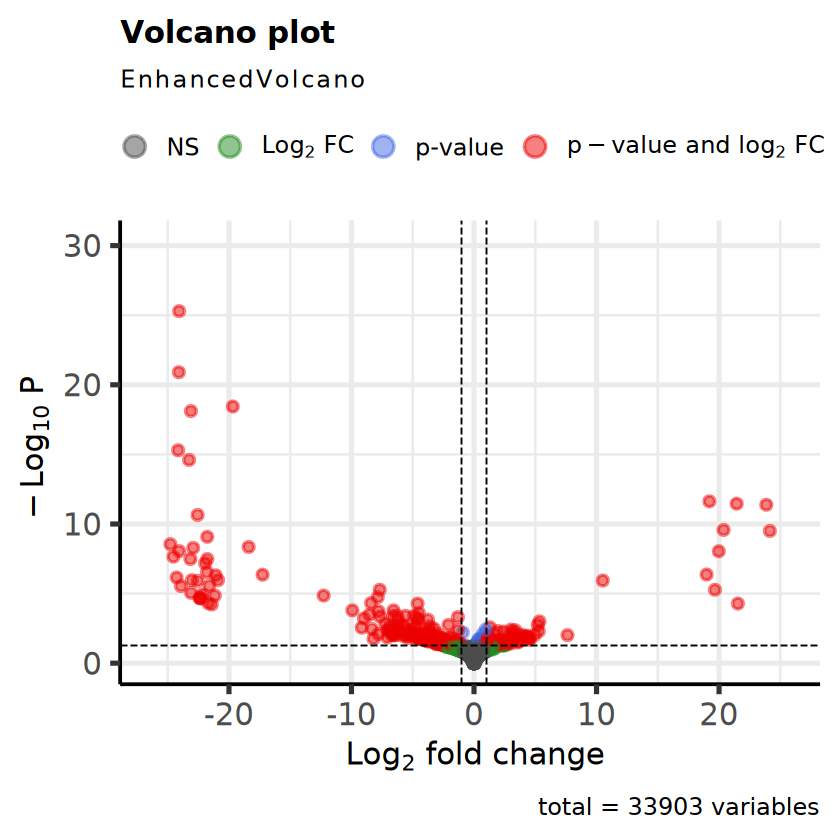

In [28]:
# phase 1 both vs. control
res.bothLFC <- lfcShrink(dds, 
                         coef=2, 
                         type = 'ashr', 
                        lfcThreshold = 1)

summary(res.bothLFC)

EnhancedVolcano(res.bothLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bothLFC <- merge(res.bothLFC, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bothLFC)[1] <- 'Gene'
head(res.bothLFC)

In [29]:
write.csv(as.data.frame(res.bothLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.both_v_cont.csv')

### other comparisons
(outside of just doing treatment vs. control)

using `ashr` for lfc shrinkage estimator (same as above)

#### warm vs. hypoxic

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28705 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 38, 0.13%
LFC < -1.00 (down) : 23, 0.08%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7661933,0.051218621,0.1224117,0.6653711,0.5058132,0.8806943,0.9926832,2271.416959,3.803795e+03,⋯,3206.1520,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,LOC144621269,6797.3813723,0.032231978,0.1938035,1.0902191,0.2756166,0.7670156,0.9810406,497.327987,1.915393e+04,⋯,9120.5983,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,LOC111120925,191.4430470,0.031224687,0.1966004,1.0924208,0.2746482,0.7663446,0.9805628,3.429848,1.722906e+01,⋯,383.2612,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,Trnae-cuc,0.0000000,0.000000000,1.1798226,NA,NA,NA,0.9734790,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
5,Trnae-cuc-2,0.0000000,0.000000000,1.1798226,NA,NA,NA,0.9441227,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
6,Trnae-cuc-3,0.3001343,0.009795103,0.2749392,0.5927874,0.5533234,NA,0.9794512,0.000000,9.571703e-01,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


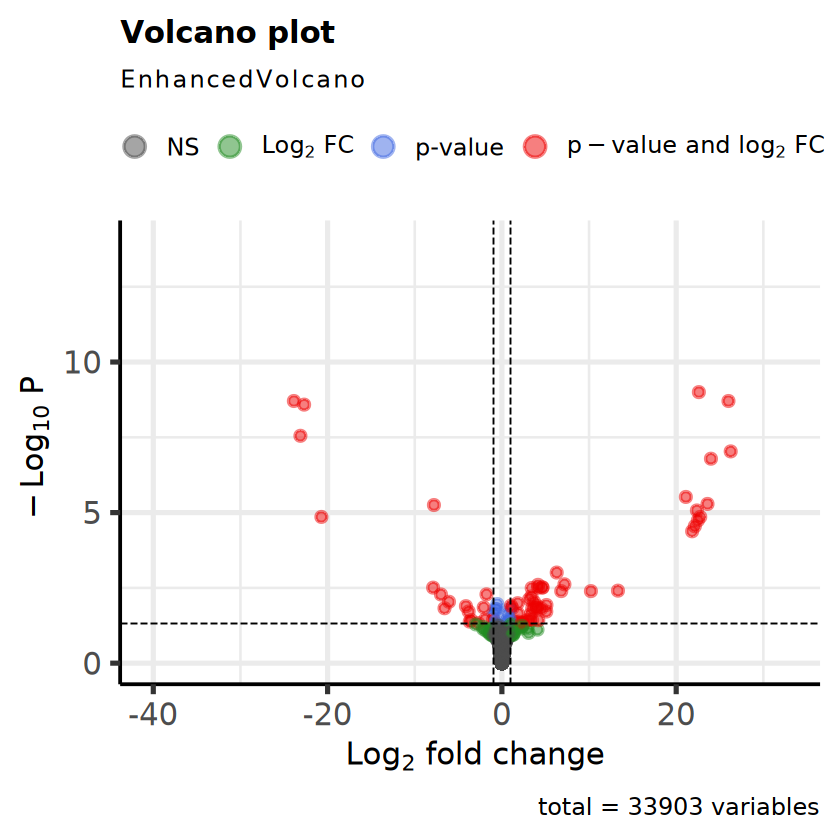

In [30]:
res.w.h <- lfcShrink(dds, 
                     contrast= c('Phase1_treatment', 'hypoxic', 'warm'), # warm is the "control"
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.w.h)

EnhancedVolcano(res.w.h,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.w.h <- merge(res.w.h, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.w.h)[1] <- 'Gene'
head(res.w.h)

In [31]:
write.csv(res.w.h, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_warm.csv')

#### warm vs. both

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28705 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 53, 0.18%
LFC < -1.00 (down) : 38, 0.13%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7661933,-0.0009944151,0.09483934,-0.02240777,0.98212269,0.9982381,0.9908965,2271.416959,3.803795e+03,⋯,3206.1520,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,LOC144621269,6797.3813723,-0.0017912365,0.12296959,-0.14012656,0.88855999,0.9871135,0.9840447,497.327987,1.915393e+04,⋯,9120.5983,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,LOC111120925,191.4430470,0.0539517673,0.33257986,1.99590438,0.04594433,0.5427303,0.8311477,3.429848,1.722906e+01,⋯,383.2612,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,Trnae-cuc,0.0000000,0.0000000000,1.29471039,NA,NA,NA,0.9162018,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
5,Trnae-cuc-2,0.0000000,0.0000000000,1.29471039,NA,NA,NA,0.9545486,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
6,Trnae-cuc-3,0.3001343,-0.0019413791,0.26371372,-0.12278983,0.90227353,NA,0.9745137,0.000000,9.571703e-01,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


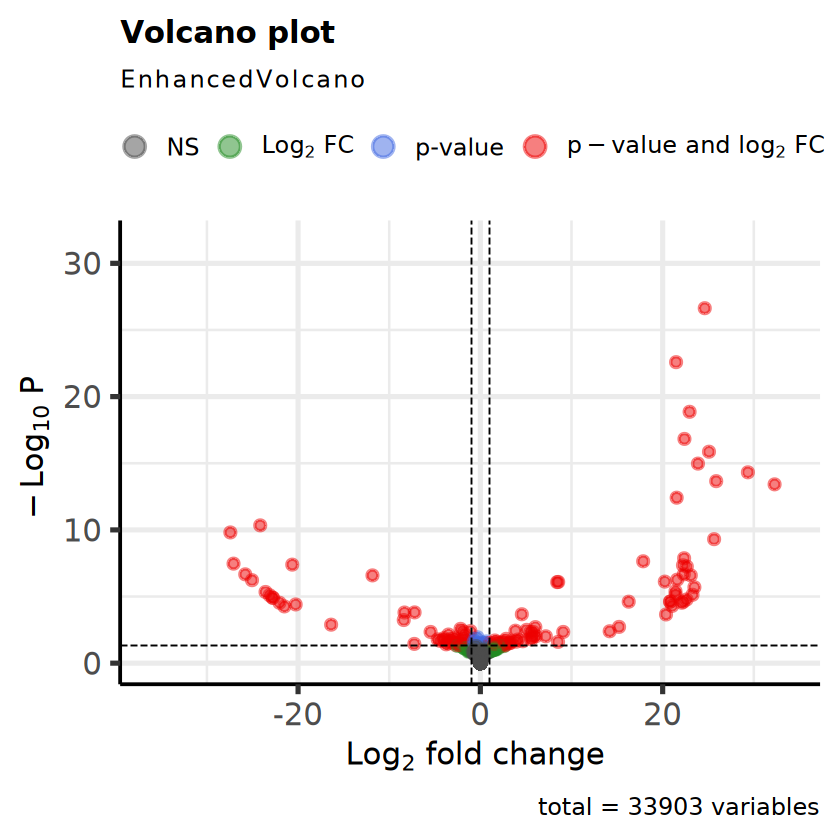

In [32]:
res.w.b <- lfcShrink(dds, 
                     contrast= c('Phase1_treatment', 'warm', 'both'), # both is the "control"
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.w.b)

EnhancedVolcano(res.w.b,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.w.b <- merge(res.w.b, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.w.b)[1] <- 'Gene'
head(res.w.b)

In [33]:
write.csv(res.w.b, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.warm_v_both.csv')

#### hypoxic vs. both

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28705 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 61, 0.21%
LFC < -1.00 (down) : 27, 0.094%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7661933,0.0002296949,0.009303662,0.6120414,0.540510399,0.9830677,0.9888970,2271.416959,3.803795e+03,⋯,3206.1520,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,LOC144621269,6797.3813723,0.0044281223,0.100087282,0.8993577,0.368462185,0.9615318,0.9745824,497.327987,1.915393e+04,⋯,9120.5983,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,LOC111120925,191.4430470,0.5934509454,1.390881770,3.0292700,0.002451455,0.1735170,0.4119482,3.429848,1.722906e+01,⋯,383.2612,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,Trnae-cuc,0.0000000,0.0000000000,1.400330932,NA,NA,NA,0.8946845,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
5,Trnae-cuc-2,0.0000000,0.0000000000,1.400330932,NA,NA,NA,0.9534056,0.000000,0.000000e+00,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
6,Trnae-cuc-3,0.3001343,0.0075719639,0.286694178,0.4408990,0.659286089,NA,0.9662315,0.000000,9.571703e-01,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


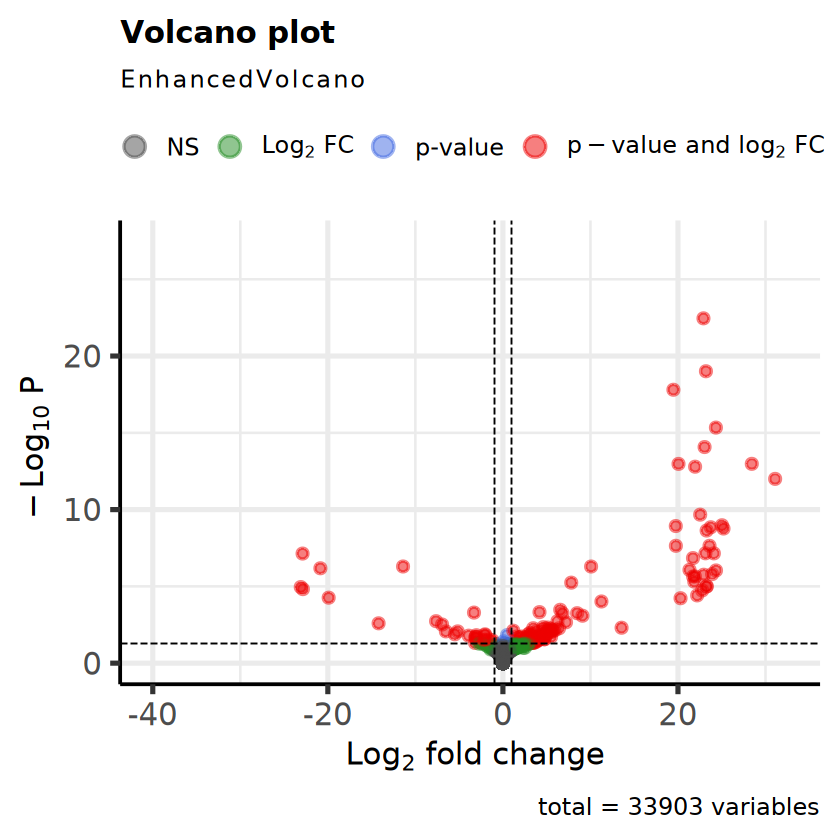

In [34]:
res.h.b <- lfcShrink(dds, 
                     contrast= c('Phase1_treatment', 'hypoxic', 'both'), # both is the "control"
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.h.b)

EnhancedVolcano(res.h.b,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.h.b <- merge(res.h.b, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.h.b)[1] <- 'Gene'
head(res.h.b)

In [35]:
write.csv(res.h.b, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_both.csv')

## DESeq - DO / warm treatments

nearly the same as above, but looking at the effect of hypoxia / warming (so normoxia includes C and W, hypoxia includes H and B; ambient includes C and H, warm includes W and B)

In [36]:
# phase 1 DO
p1_meta$Phase1_DO <- factor(p1_meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

In [37]:
# phase 1 tempature
p1_meta$Phase1_temp <- factor(p1_meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

In [38]:
head(p1_meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA


### phase 1 temperature
only comparing warming vs ambient (so some treatments are getting lumped together)

In [39]:
# creating DESeq2 object
dds_temp <- DESeqDataSetFromMatrix(countData = p1_counts,
                              colData = p1_meta,
                              design = ~ Phase1_temp)
dds_temp

# running DESeq
dds_temp <- DESeq(dds_temp)

# list coefficients
resultsNames(dds_temp)

class: DESeqDataSet 
dim: 33903 23 
metadata(1): version
assays(1): counts
rownames(33903): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(8): Phase1_treatment Phase1_temp ... Phase2_DO
  Phase2_TankRep

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2084 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



[1] "Intercept"                   "Phase1_temp_warm_vs_ambient"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28677 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 7, 0.024%
LFC < -1.00 (down) : 14, 0.049%



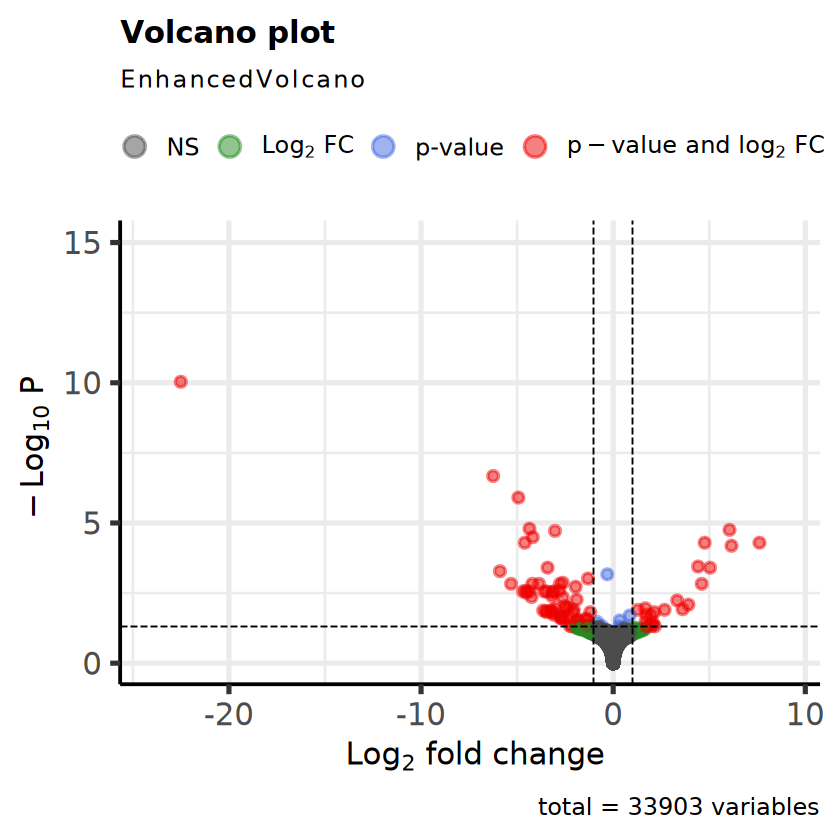

In [40]:
res.warm <- lfcShrink(dds_temp, 
                     coef = ('Phase1_temp_warm_vs_ambient'), 
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.warm)

EnhancedVolcano(res.warm,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

interesting that there's not nearly as many DEGs when you only look at ambient vs. warm treatment ...

In [41]:
write.csv(res.warm, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/warm_v_ambient.csv')

### phase 1 DO
only comparing normoxia vs hypoxia (so some treatments are getting lumped together)

In [42]:
# creating DESeq2 object
dds_DO <- DESeqDataSetFromMatrix(countData = p1_counts,
                              colData = p1_meta,
                              design = ~ Phase1_DO)
dds_DO

# running DESeq
dds_DO <- DESeq(dds_DO)

# list coefficients
resultsNames(dds_DO)

class: DESeqDataSet 
dim: 33903 23 
metadata(1): version
assays(1): counts
rownames(33903): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(8): Phase1_treatment Phase1_temp ... Phase2_DO
  Phase2_TankRep

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2001 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



[1] "Intercept"                     "Phase1_DO_hypoxic_vs_normoxic"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28677 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 5, 0.017%
LFC < -1.00 (down) : 3, 0.01%



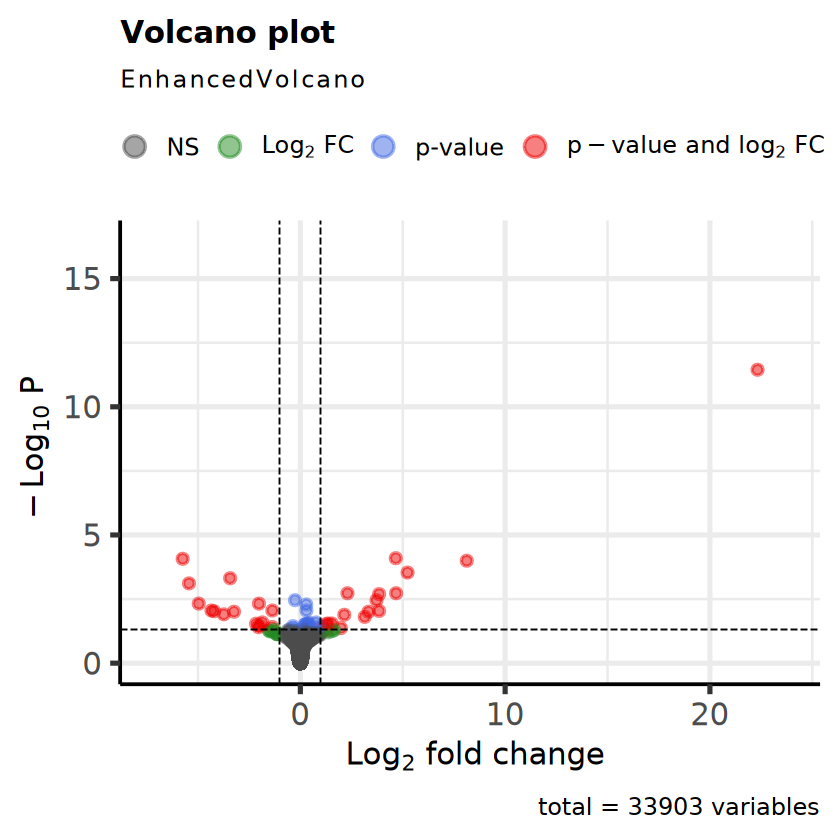

In [43]:
res.DO <- lfcShrink(dds_DO, 
                     coef = ('Phase1_DO_hypoxic_vs_normoxic'), 
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.DO)

EnhancedVolcano(res.DO,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

same thing as temperature, not as many DEGs as when separating by treatment

In [44]:
write.csv(res.DO, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/hypoxic_v_normoxic.csv')

### nMDS with only significant DEGs

In [54]:
# pull out all DEGs identified in any pairwise comparison
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
# want to keep only the dfs for full treatment comparisons - not isolated comparisons
geneList <- geneList[startsWith(names(geneList), "p1")]
names(geneList)

[1] "p1.both_v_cont" "p1.hyp_v_both"  "p1.hyp_v_cont"  "p1.hyp_v_warm" 
[5] "p1.warm_v_both" "p1.warm_v_cont"

In [60]:
# pull out DEGs in these dfs
degs <- lapply(geneList, function(df) {
      subset(df, abs(log2FoldChange) >= 1 & padj <= 0.05)
    })
head(degs$p1.both_v_cont)

,X,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,3,LOC111120925,191.44305,-4.816061,1.434592,-4.432787,9.302274e-06,0.0030326606,0.003332593,3.429848,⋯,383.261217,14.374893,246.710448,219.685794,6.742502,337.801055,5.5715422,6.466452,0.000000,13.843829
211,211,LOC111103173,15.14959,4.365504,2.025135,4.039598,5.354287e-05,0.0106991246,0.022951093,129.476769,⋯,2.546586,6.708283,1.036599,2.630968,10.488336,0.000000,0.9285904,16.628020,0.000000,0.000000
232,232,LOC144622019,14.43126,-21.685053,4.272431,-5.354808,8.564740e-08,0.0000483984,0.000161978,0.000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
327,327,LOC111105159,57.17908,-5.199942,2.588591,-4.075872,4.584228e-05,0.0096385781,0.027797446,0.000000,⋯,1.273293,1.916652,1.036599,2.630968,1.498334,3.568321,0.0000000,3.695116,1.984959,0.000000
510,510,LOC111132252,110.19476,-2.635506,2.006382,-3.633249,2.798748e-04,0.0327889602,0.092730666,0.000000,⋯,146.428704,32.583090,350.370300,388.067720,35.210841,114.186272,43.6437471,15.704241,248.119838,3.775590
516,516,LOC111137262,591.06709,3.622591,3.009049,3.696540,2.185576e-04,0.0280691987,0.102579351,1.714924,⋯,2942.580305,1106.866737,13.475781,0.000000,4.495001,2653.641385,1.8571807,2366.721529,6.947355,7.551179


In [70]:
# create list of all DEGs from the four dfs
all_degs <- degs %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 429 total DEGs
head(all_degs)

[1] 429

[1] "LOC111120925" "LOC111103173" "LOC144622019" "LOC111105159" "LOC111132252"
[6] "LOC111137262"

In [71]:
vsd_mat <- assay(vsd)

degs_vsd <- vsd_mat[rownames(vsd_mat) %in% all_degs, ]

dim(degs_vsd) # 429 total DEGs kept
head(degs_vsd)

[1] 429  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC111120925,6.790123,7.133028,7.222546,6.738875,6.949505,7.169359,9.046805,9.069082,8.527882,6.843712,⋯,9.104683,7.079873,8.675046,8.570575,6.901862,8.976325,6.866471,6.893820,6.510761,7.069393
LOC144621391,6.510761,6.510761,7.318804,8.320611,6.510761,8.001540,6.510761,6.510761,6.510761,6.510761,⋯,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761
LOC144619144,6.905226,6.952462,6.706305,6.905049,6.510761,6.978463,7.955667,6.999780,8.089730,7.028005,⋯,7.245884,7.166524,6.817821,7.487426,7.783293,6.878205,8.260288,8.053211,8.585076,6.750179
LOC111103995,11.548996,12.622945,13.748478,13.152400,12.615797,13.140941,12.136580,12.391057,11.541497,13.309009,⋯,11.515983,13.716220,12.232161,11.007140,11.721038,11.266737,10.240734,10.172899,10.852696,10.959815
LOC111103173,8.141636,6.510761,7.329970,6.870880,8.124059,6.710904,6.510761,6.510761,6.510761,6.689013,⋯,6.751576,6.900875,6.664508,6.755523,6.997730,6.510761,6.656286,7.122240,6.510761,6.510761
LOC144622019,6.510761,6.510761,6.510761,6.510761,6.510761,8.486634,6.510761,6.510761,6.510761,8.158259,⋯,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761


In [72]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.00000,25.58809,23.65612,26.39485,23.91285,29.23215,43.71596,42.99310,38.60694,28.86188,⋯,48.89620,26.48993,43.01986,31.68411,28.81443,41.81191,30.06913,30.15387,27.82811,28.10422
B2_Nu_O12,25.58809,0.00000,24.36756,27.07157,27.73877,26.26659,42.67010,42.74913,36.66925,26.72199,⋯,47.58784,25.77819,41.98810,27.81225,27.49891,39.62035,28.39594,30.98403,24.92026,27.47155
B4_Nu_O32,23.65612,24.36756,0.00000,21.49228,26.79378,26.47637,41.25209,40.53027,34.77507,25.40617,⋯,46.70719,19.02486,39.87266,26.42757,24.14030,39.14790,28.70278,27.51609,25.37509,25.16858
B5_Nu_O36,26.39485,27.07157,21.49228,0.00000,27.76026,28.35673,43.27916,42.93540,37.09021,28.79380,⋯,48.83519,22.82974,41.29170,30.19629,25.22638,42.87433,32.43042,29.74360,29.24598,26.98244
B6_Nu_O47,23.91285,27.73877,26.79378,27.76026,0.00000,31.55971,45.38393,44.75822,40.00159,30.73354,⋯,47.26734,26.44299,43.35675,34.77627,29.40650,43.54514,34.00883,30.12778,31.12411,30.13337
C1_Nu_W01,29.23215,26.26659,26.47637,28.35673,31.55971,0.00000,38.80417,39.09879,34.56847,22.28334,⋯,47.64610,24.77797,39.56868,26.21444,24.19144,39.63593,28.81359,27.22986,24.62407,22.82963


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>
B1_Nu_O03,-12.758954,-9.100383,both,warm,hypoxic,1,NA,NA,NA,NA,1.1662324
B2_Nu_O12,-11.613427,-3.455909,both,warm,hypoxic,2,NA,NA,NA,NA,1.0447462
B4_Nu_O32,-11.302369,-5.853357,both,warm,hypoxic,4,NA,NA,NA,NA,1.1920377
B5_Nu_O36,-12.514332,-9.224793,both,warm,hypoxic,5,NA,NA,NA,NA,0.8754641
B6_Nu_O47,-12.634810,-13.249466,both,warm,hypoxic,6,NA,NA,NA,NA,0.9413226
C1_Nu_W01,-9.291786,3.105537,control,ambient,normoxic,1,NA,NA,NA,NA,1.1378061


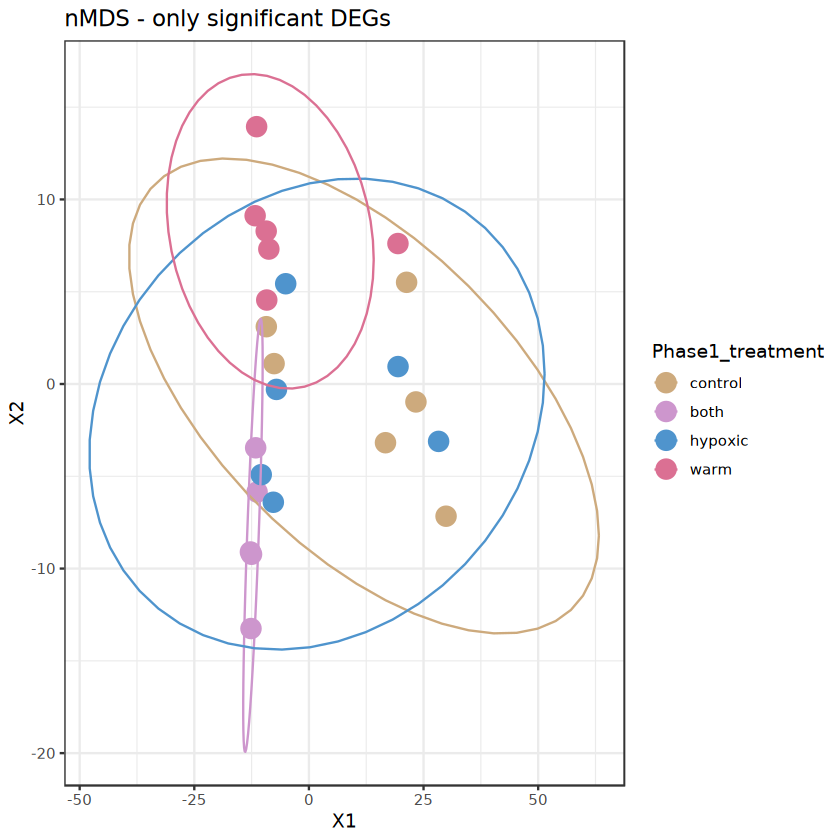

In [73]:
ggplot(mds, aes(X1, X2, col = Phase1_treatment)) +
geom_point(size = 5) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
stat_ellipse() + 
labs(title = 'nMDS - only significant DEGs') +
theme_bw()

In [74]:
meta3 <- meta2[meta2$Sample %in% rownames(mds),]

#### permanova

In [75]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO , data = meta3, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,1926.6132,0.14972927,3.956629,0.004
Phase1_DO,1,1032.7009,0.08025771,2.120828,0.055
Phase1_temp:Phase1_DO,1,656.2702,0.05100290,1.347763,0.159
Residual,19,9251.7269,0.71901011,NA,NA
Total,22,12867.3113,1.00000000,NA,NA


significant effect of phase 1 temp, phase 1 DO no longer has a significant effect, and no interaction of the two stressors (there wasn't any significant effects when we looked at all genes, but once limited to significant DEGs idnetified in any pairwise comparison (not isolated treatments), we saw significant effects on GE profiles)

### nMDS with only significant DEGs from 'isolated' treatments

In [76]:
# pull out DEGs identified 

# read in dfs
do <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/hypoxic_v_normoxic.csv')
temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/warm_v_ambient.csv')

# merge
degs <- rbind(do, temp) %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1) 

deg_list <- unique(degs$X)
length(deg_list)# 112 total DEGs
head(deg_list)

[1] 112

[1] "LOC144621391" "LOC111105442" "LOC144622706" "LOC111105472" "LOC144625532"
[6] "LOC111101639"

In [77]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% deg_list,]

dim(degs_vsd) # 112 total DEGs kept
head(degs_vsd)

[1] 112  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC144621391,6.510761,6.510761,7.318804,8.320611,6.510761,8.001540,6.510761,6.510761,6.510761,6.510761,⋯,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761,6.510761
LOC111105159,6.510761,6.510761,6.706305,6.833028,6.666404,6.510761,8.914365,8.593003,6.510761,6.510761,⋯,6.681142,6.719739,6.664508,6.755523,6.695567,6.795688,6.510761,6.800690,6.723423,6.510761
LOC111103328,6.650606,6.805865,9.955308,6.833028,6.510761,7.768651,9.673331,9.950574,9.526332,8.817194,⋯,14.648415,8.220345,9.265948,9.273407,7.594678,10.101981,6.894810,8.047509,6.723423,6.750179
LOC111105442,7.146698,8.906767,7.284240,7.189537,11.856483,7.371060,7.326240,7.045949,6.643965,6.908338,⋯,11.146510,6.976433,6.728090,7.643818,6.771938,6.675442,7.071085,6.761952,6.771101,7.260277
LOC144622706,7.066908,7.241957,10.459405,7.276131,9.936938,6.710904,6.822496,7.023406,7.116926,6.689013,⋯,8.699608,9.701610,9.398481,6.510761,7.031004,7.100729,6.510761,7.392116,6.811240,6.803819
LOC111105472,11.976063,7.227483,6.750162,6.833028,12.004151,7.212017,6.510761,7.451832,6.699073,6.908338,⋯,11.339882,7.182435,6.510761,6.856495,7.253721,7.885149,6.762604,7.229351,7.029350,6.510761


In [78]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.00000,11.84473,18.24177,15.76274,14.16429,16.63806,21.86969,21.68486,18.92424,15.89870,⋯,25.07755,17.025016,20.72874,17.29600,14.34823,19.84043,13.97531,14.49698,12.99331,14.74154
B2_Nu_O12,11.84473,0.00000,16.83787,15.10134,15.21208,17.29667,23.09854,21.83036,19.32870,16.29907,⋯,25.36606,16.727082,22.32775,16.47942,13.46594,20.76841,15.63465,15.27151,12.37967,16.37181
B4_Nu_O32,18.24177,16.83787,0.00000,17.18903,19.98345,15.32962,23.64005,21.92367,20.41654,18.17115,⋯,25.23599,9.424038,22.57647,16.54417,15.98439,21.79285,19.65342,13.16281,17.91406,18.19751
B5_Nu_O36,15.76274,15.10134,17.18903,0.00000,16.99970,16.96839,21.72771,20.54684,17.71130,15.97003,⋯,26.21345,15.526066,20.05439,16.14428,11.86029,22.52276,19.01342,12.64498,15.07494,14.97716
B6_Nu_O47,14.16429,15.21208,19.98345,16.99970,0.00000,17.06570,24.28520,22.61635,20.65570,18.20244,⋯,24.07238,18.932294,22.47110,19.20920,14.96165,23.61858,20.40519,15.89998,17.01460,17.47261
C1_Nu_W01,16.63806,17.29667,15.32962,16.96839,17.06570,0.00000,21.49654,21.18379,18.20211,14.47162,⋯,24.58423,13.186632,22.44218,16.39251,15.00263,21.81209,18.18042,13.35709,16.71225,16.66953


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>
B1_Nu_O03,-5.680767,-4.6924953,both,warm,hypoxic,1,NA,NA,NA,NA,1.1662324
B2_Nu_O12,-6.108294,-3.4034401,both,warm,hypoxic,2,NA,NA,NA,NA,1.0447462
B4_Nu_O32,-5.490301,4.8703077,both,warm,hypoxic,4,NA,NA,NA,NA,1.1920377
B5_Nu_O36,-5.290668,2.5007523,both,warm,hypoxic,5,NA,NA,NA,NA,0.8754641
B6_Nu_O47,-5.411973,0.7418062,both,warm,hypoxic,6,NA,NA,NA,NA,0.9413226
C1_Nu_W01,-4.748523,3.7080207,control,ambient,normoxic,1,NA,NA,NA,NA,1.1378061


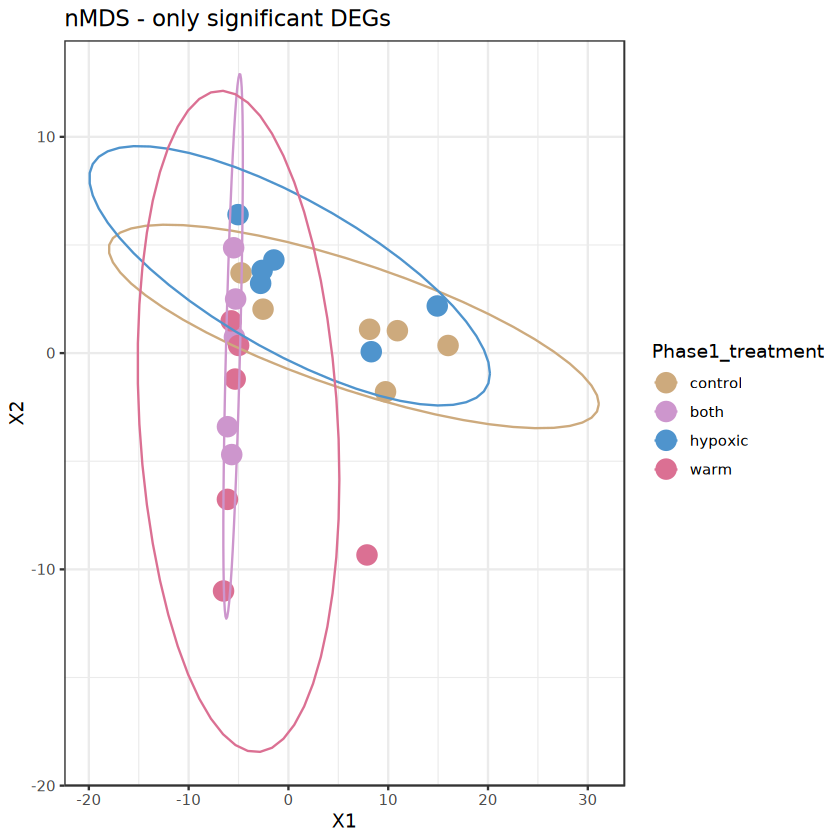

In [79]:
ggplot(mds, aes(X1, X2, col = Phase1_treatment)) +
geom_point(size = 5) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
stat_ellipse() + 
labs(title = 'nMDS - only significant DEGs') +
theme_bw()

different patterns here vs. when we looked at all DEGs identified in any pairwise comparisons for phase 1 vs. phase 1
- warm is more dispersed
- both has tigher clustering

#### permanova

In [80]:
meta3 <- meta2[meta2$Sample %in% rownames(mds),]

In [81]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO , data = meta3, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,595.9570,0.15251716,3.8600353,0.002
Phase1_DO,1,273.7817,0.07006615,1.7732943,0.072
Phase1_temp:Phase1_DO,1,104.2960,0.02669140,0.6755288,0.786
Residual,19,2933.4402,0.75072529,NA,NA
Total,22,3907.4748,1.00000000,NA,NA
